# Duration distribution comparison

Compare generated duration and speed plots for the full dataset and the dataset without station-continuity discontinuities.


In [21]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for path in [current, *current.parents]:
        if (path / "Data").exists():
            return path
    raise FileNotFoundError("Could not find project root containing Data/")


PROJECT_ROOT = find_project_root()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "Data"
PRESENTATION_DIR = PROJECT_ROOT / "notebooks" / "04_data_presentation"

if str(PRESENTATION_DIR) not in sys.path:
    sys.path.insert(0, str(PRESENTATION_DIR))

import duration_plot_utils as dpu


## ---------- Dataset configuration ----------


In [22]:
DATASETS = {
    "Pełny zbiór": DATA_DIR / "final_trip_data.parquet",
    "Bez nieciągłości": DATA_DIR / "rides_data_without_discontinuities.parquet",
}

lower_limit = 3
upper_limit = 180
selected_duration_range_label = f"{lower_limit}-{upper_limit} min"
full_duration_range_label = "pełny dodatni zakres czasu"
a_values = [1.5, 1.75, 2]
speed_a_values = [1.5, 1.75, 2]

DATASETS


{'Pełny zbiór': PosixPath('/Users/artur/Studia/Rowerki/Data/final_trip_data.parquet'),
 'Bez nieciągłości': PosixPath('/Users/artur/Studia/Rowerki/Data/rides_data_without_discontinuities.parquet')}

## ---------- Preparing outputs for both datasets ----------


In [23]:
outputs_by_dataset = {}

for dataset_name, data_file in DATASETS.items():
    print("=" * 80)
    print(dataset_name)
    print(data_file)

    outputs_by_dataset[dataset_name] = dpu.prepare_dataset_outputs(
        data_file,
        lower_limit=lower_limit,
        upper_limit=upper_limit,
        a_values=a_values,
        speed_a_values=speed_a_values,
    )


Pełny zbiór
/Users/artur/Studia/Rowerki/Data/final_trip_data.parquet
Liczba przejazdów w zakresie 3-180 min: 16655915
Liczba wszystkich przejazdów: 17426293
Udział danych w tym zakresie: 95.58%

a = 1.5
Number of bins: 11
First bin edges: [ 3.      4.5     6.75   10.125  15.1875]
Last bin edges: [ 51.2578125   76.88671875 115.33007812 172.99511719 180.        ]

a = 1.75
Number of bins: 8
First bin edges: [ 3.          5.25        9.1875     16.078125   28.13671875]
Last bin edges: [ 28.13671875  49.23925781  86.16870117 150.79522705 180.        ]

a = 2
Number of bins: 6
First bin edges: [ 3  6 12 24 48]
Last bin edges: [ 12  24  48  96 180]
Liczba przejazdów w zakresie 3-180 min z policzoną prędkością: 16223608

a = 1.5
Number of bins: 24
First bin edges: [0.00527694 0.00791541 0.01187312 0.01780968 0.02671452]
Last bin edges: [17.54718795 26.32078193 39.4811729  59.22175935 68.40017186]

a = 1.75
Number of bins: 17
First bin edges: [0.00527694 0.00923465 0.01616064 0.02828111 0.0494

In [24]:
comparison_summary = dpu.comparison_summary(outputs_by_dataset)
comparison_summary


,dataset,liczba_wszystkich_przejazdow,liczba_przejazdow_w_zakresie,udzial_w_zakresie_%,liczba_przejazdow_z_predkoscia,min_speed_km_h,max_speed_km_h
0,Pełny zbiór,17426293,16655915,95.579220,16223608,0.005277,68.400172
1,Bez nieciągłości,16091818,15377692,95.562179,14977630,0.005277,68.400172


## ---------- Para 1: zakres czasu 3-180 min ----------


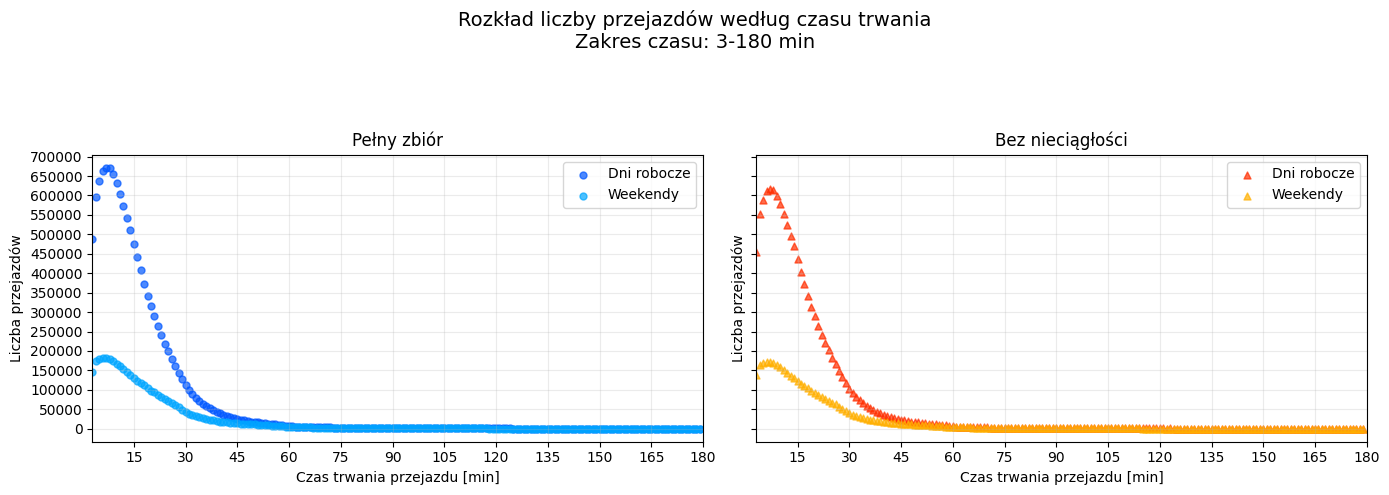

In [25]:
# ---------- Duration counts: weekdays vs weekends ----------

fig, axes = dpu.plot_duration_counts_dataset_comparison(
    outputs_by_dataset,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    range_label=selected_duration_range_label,
)
plt.show()


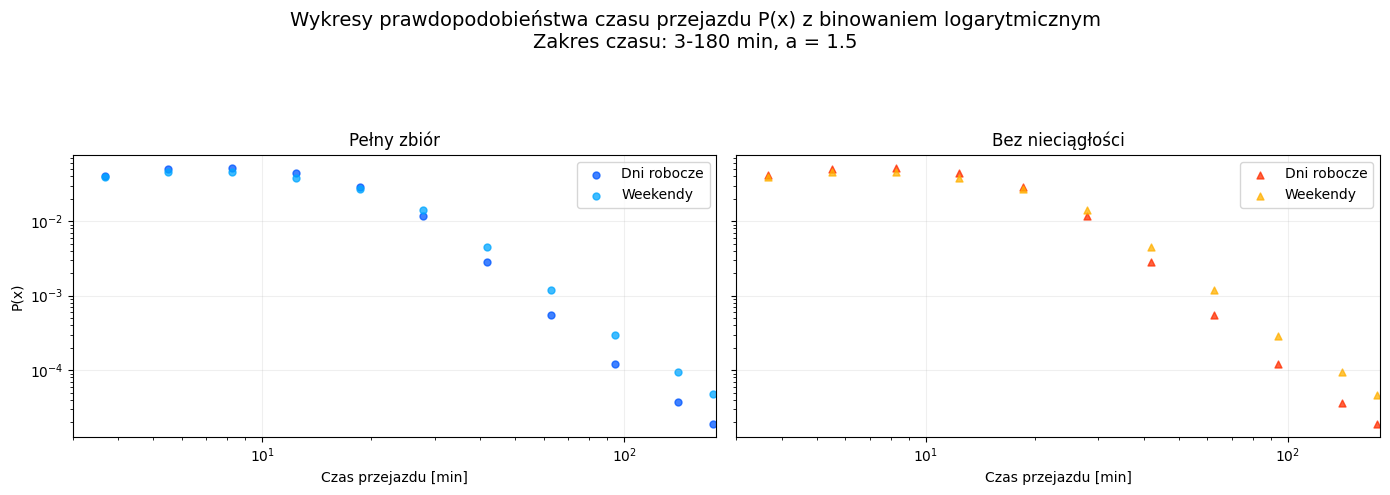

In [26]:
# ---------- Plotting logarithmic probability density ----------

fig, axes = dpu.plot_duration_log_probability_dataset_comparison(
    outputs_by_dataset,
    a_value=1.5,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    range_label=selected_duration_range_label,
)
plt.show()


Zakres dopasowania:
x_min = 15
x_max = 180

Dni robocze:
Nachylenie = -3.396
Wyraz wolny = 2.874

Weekendy:
Nachylenie = -2.936
Wyraz wolny = 2.307
Zakres dopasowania:
x_min = 15
x_max = 180

Dni robocze:
Nachylenie = -3.402
Wyraz wolny = 2.884

Weekendy:
Nachylenie = -2.947
Wyraz wolny = 2.324


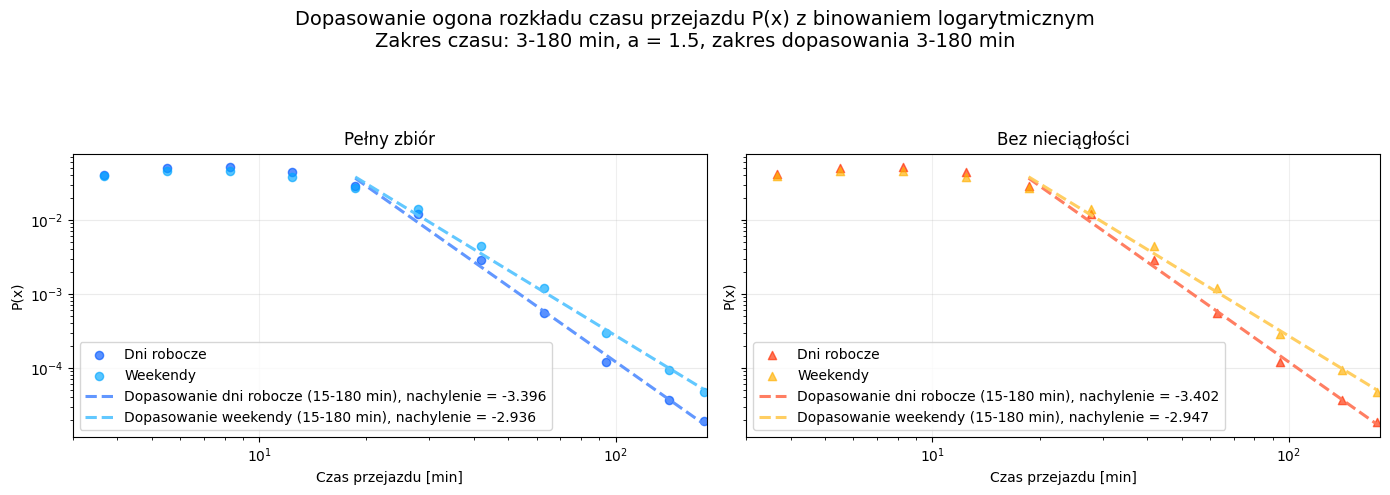

In [27]:
# ---------- Separate tail fits for weekdays and weekends ----------

tail_fits = {}
fig, axes = plt.subplots(
    1,
    len(outputs_by_dataset),
    figsize=(7 * len(outputs_by_dataset), 5),
    sharex=True,
    sharey=True,
)

if len(outputs_by_dataset) == 1:
    axes = [axes]

for ax, (dataset_name, outputs) in zip(axes, outputs_by_dataset.items()):
    tail_fits[dataset_name] = dpu.plot_duration_tail_fit(
        outputs["duration_results"],
        lower_limit=lower_limit,
        upper_limit=upper_limit,
        a_value=1.5,
        x_min=15,
        x_max=180,
        ax=ax,
        colors=dpu.dataset_day_type_colors(dataset_name),
        marker=dpu.dataset_marker(dataset_name),
    )
    ax.set_title(dataset_name)

fig.suptitle(
    "Dopasowanie ogona rozkładu czasu przejazdu P(x) z binowaniem logarytmicznym\n"
    f"Zakres czasu: {selected_duration_range_label}, a = 1.5, zakres dopasowania {lower_limit}-{upper_limit} min",
    fontsize=14,
)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()


# Histogram prędkości


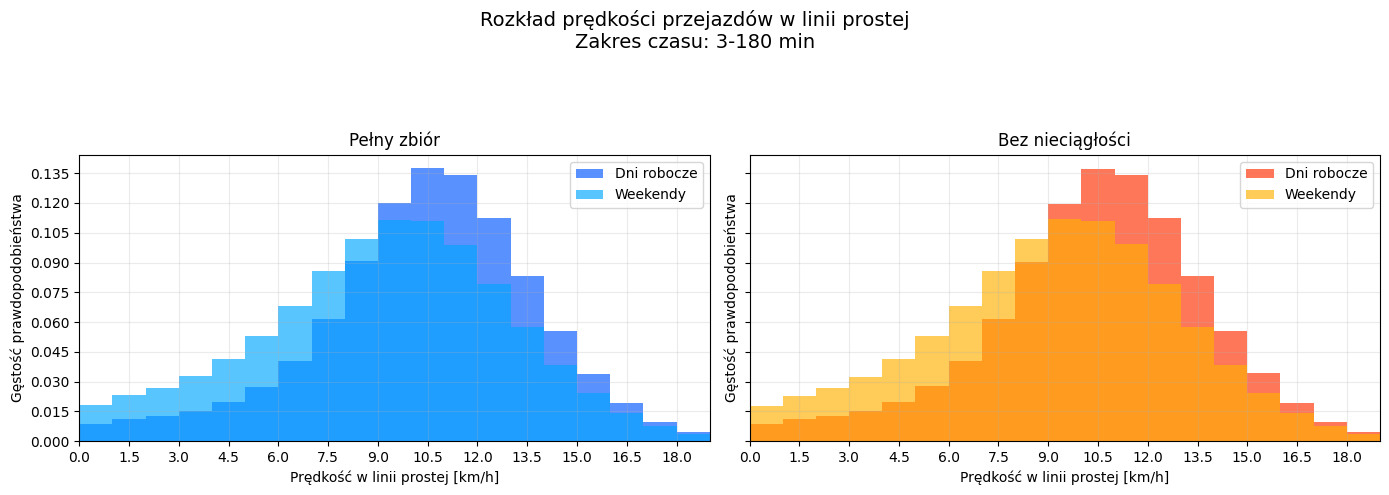

In [28]:
# ---------- Speed distribution for rides within the selected duration range ----------

fig, axes = dpu.plot_speed_histogram_dataset_comparison(
    outputs_by_dataset,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    range_label=selected_duration_range_label,
)
plt.show()


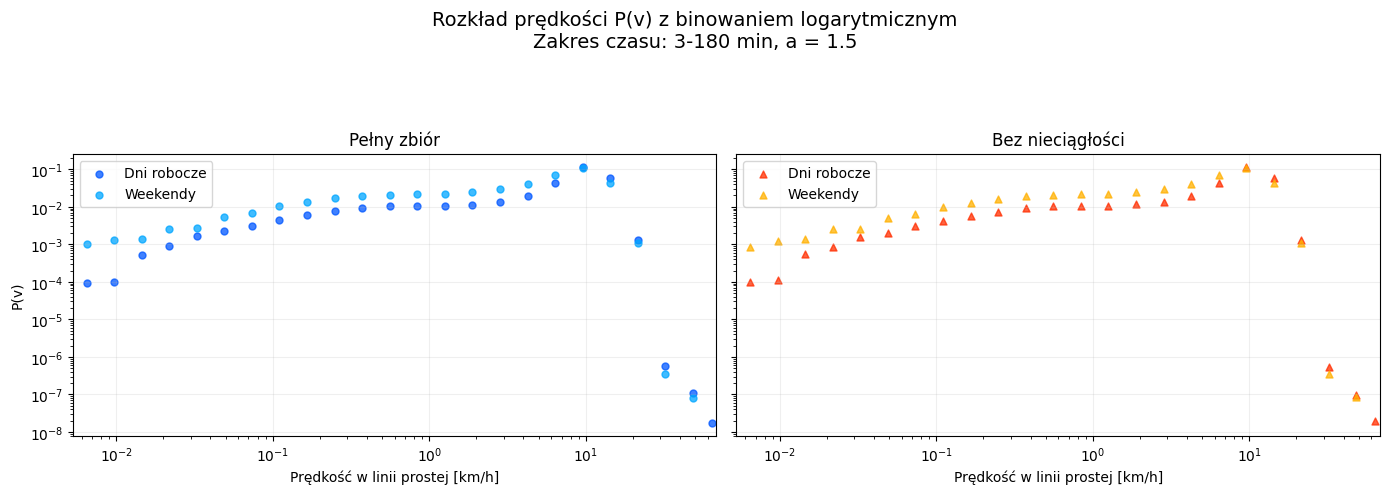

In [29]:
# ---------- Logarithmic speed distribution ----------

fig, axes = dpu.plot_speed_log_probability_dataset_comparison(
    outputs_by_dataset,
    a_value=1.5,
    range_label=selected_duration_range_label,
)
plt.show()


## ---------- Wykresy nałożone: zakres czasu 3-180 min ----------


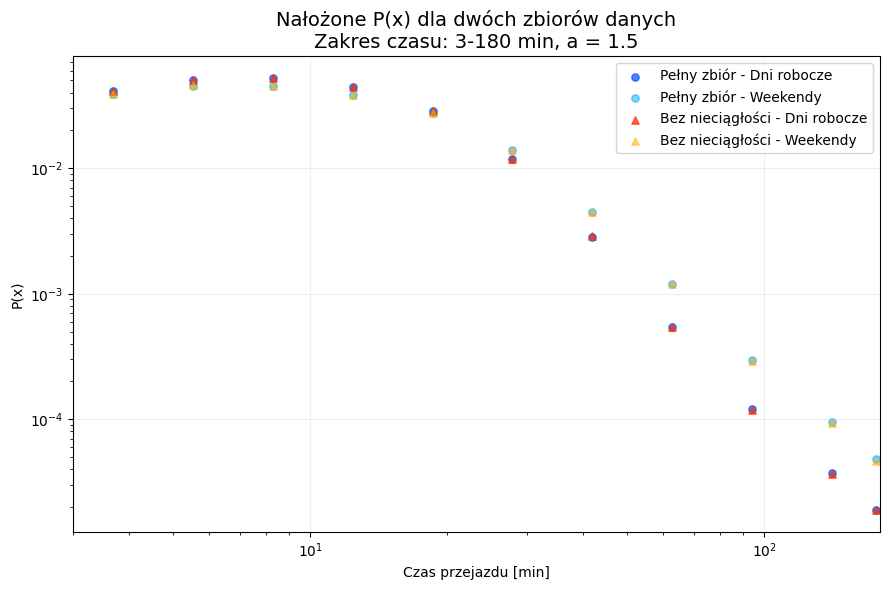

In [30]:
# ---------- Overlaid duration log-probability plots ----------

fig, ax = dpu.plot_duration_log_probability_dataset_overlay(
    outputs_by_dataset,
    a_value=1.5,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    range_label=selected_duration_range_label,
)
plt.show()


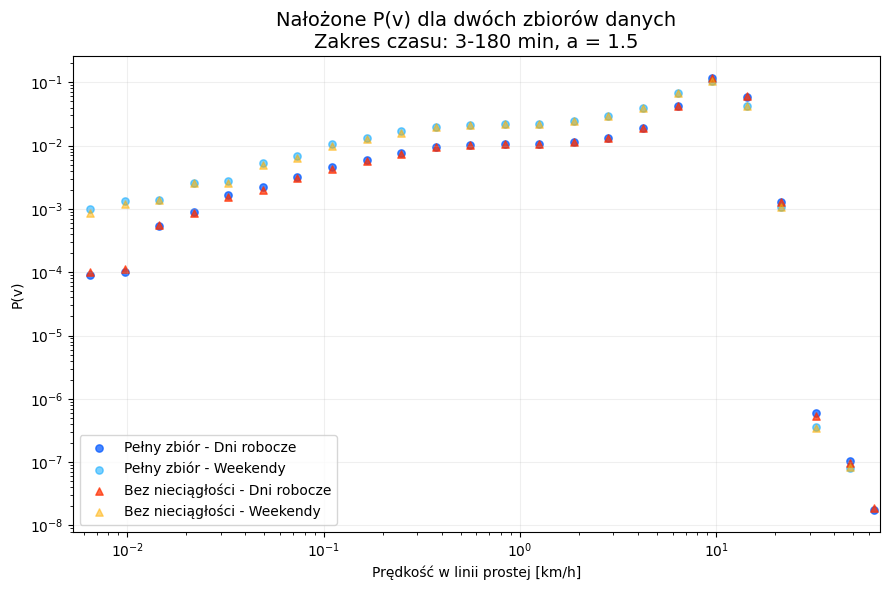

In [31]:
# ---------- Overlaid speed log-probability plots ----------

fig, ax = dpu.plot_speed_log_probability_dataset_overlay(
    outputs_by_dataset,
    a_value=1.5,
    range_label=selected_duration_range_label,
)
plt.show()


## ---------- Para 2: pełny zakres czasu ----------


In [32]:
# ---------- Preparing duration results for the full positive time range ----------

full_range_limits = []

for dataset_name, outputs in outputs_by_dataset.items():
    duration_values = outputs["dur_dist_data"]["total_duration_minutes"]
    positive_duration_values = duration_values[
        duration_values.notna()
        & np.isfinite(duration_values)
        & (duration_values > 0)
    ]

    full_range_limits.append(
        (positive_duration_values.min(), positive_duration_values.max())
    )

full_lower_limit = min(limit[0] for limit in full_range_limits)
full_upper_limit = max(limit[1] for limit in full_range_limits)

print(f"Pełny dodatni zakres czasu: {full_lower_limit:.6f}-{full_upper_limit:.2f} min")

full_range_outputs_by_dataset = {}

for dataset_name, outputs in outputs_by_dataset.items():
    dur_dist_data_weekdays = outputs["dur_dist_data_weekdays"]
    dur_dist_data_weekends = outputs["dur_dist_data_weekends"]

    duration_counts_weekdays, duration_counts_weekends = dpu.count_rides_by_duration(
        dur_dist_data_weekdays,
        dur_dist_data_weekends,
        lower_limit=full_lower_limit,
        upper_limit=full_upper_limit,
    )

    duration_weekdays, duration_weekends = dpu.prepare_duration_data(
        dur_dist_data_weekdays,
        dur_dist_data_weekends,
        lower_limit=full_lower_limit,
        upper_limit=full_upper_limit,
    )

    duration_results = dpu.calculate_duration_log_binning_results(
        duration_weekdays,
        duration_weekends,
        lower_limit=full_lower_limit,
        upper_limit=full_upper_limit,
        a_values=a_values,
    )

    full_range_outputs_by_dataset[dataset_name] = {
        **outputs,
        "duration_counts_weekdays": duration_counts_weekdays,
        "duration_counts_weekends": duration_counts_weekends,
        "duration_weekdays": duration_weekdays,
        "duration_weekends": duration_weekends,
        "duration_results": duration_results,
    }


Pełny dodatni zakres czasu: 0.003267-272120.61 min

a = 1.5
Number of bins: 45
First bin edges: [0.00326667 0.0049     0.00735    0.011025   0.0165375 ]
Last bin edges: [ 54180.92837261  81271.39255891 121907.08883836 182860.63325755
 272120.61363333]

a = 1.75
Number of bins: 33
First bin edges: [0.00326667 0.00571667 0.01000417 0.01750729 0.03063776]
Last bin edges: [ 36492.88788627  63862.55380098 111759.46915171 195579.0710155
 272120.61363333]

a = 2
Number of bins: 27
First bin edges: [0.00326667 0.00653333 0.01306667 0.02613333 0.05226667]
Last bin edges: [ 27402.78613333  54805.57226667 109611.14453333 219222.28906667
 272120.61363333]

a = 1.5
Number of bins: 45
First bin edges: [0.00326667 0.0049     0.00735    0.011025   0.0165375 ]
Last bin edges: [ 54180.92837261  81271.39255891 121907.08883836 182860.63325755
 272120.61363333]

a = 1.75
Number of bins: 33
First bin edges: [0.00326667 0.00571667 0.01000417 0.01750729 0.03063776]
Last bin edges: [ 36492.88788627  63862.5538

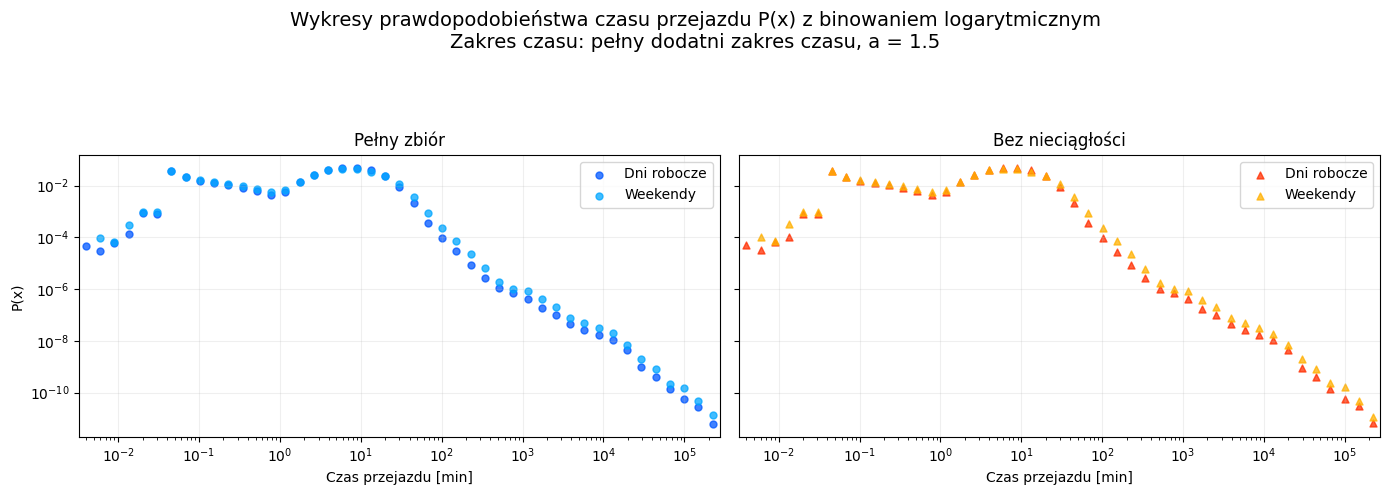

In [33]:
# ---------- Full-range duration log-probability comparison ----------

fig, axes = dpu.plot_duration_log_probability_dataset_comparison(
    full_range_outputs_by_dataset,
    a_value=1.5,
    lower_limit=full_lower_limit,
    upper_limit=full_upper_limit,
    range_label=full_duration_range_label,
)
plt.show()


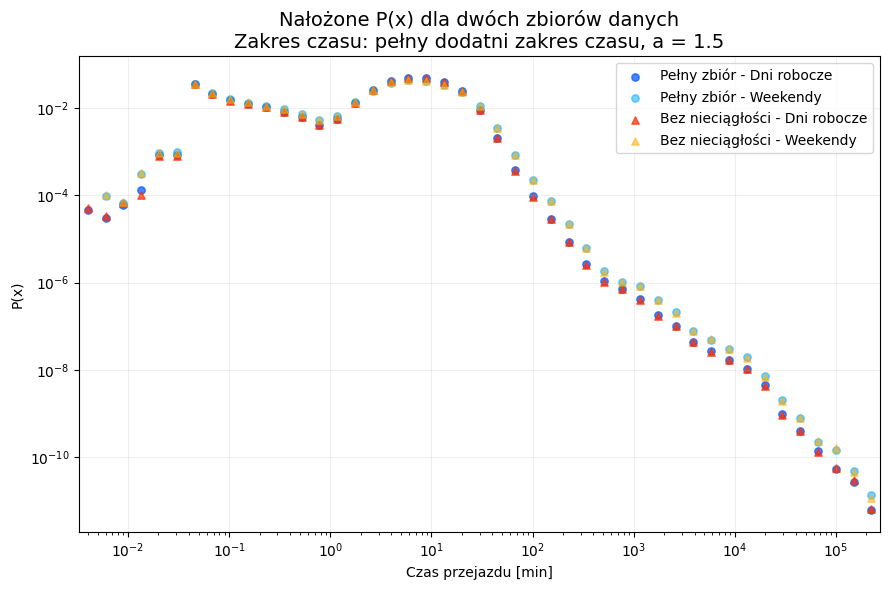

In [34]:
# ---------- Full-range overlaid duration log-probability comparison ----------

fig, ax = dpu.plot_duration_log_probability_dataset_overlay(
    full_range_outputs_by_dataset,
    a_value=1.5,
    lower_limit=full_lower_limit,
    upper_limit=full_upper_limit,
    range_label=full_duration_range_label,
)
plt.show()


## ---------- Numerical distribution differences ----------


In [35]:
# ---------- Numerical comparison for the plotted range ----------

metric_sample_size = 1_000_000

main_distribution_difference = dpu.distribution_difference_summary(
    outputs_by_dataset,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    variables=("total_duration_minutes", "speed_km_per_h"),
    subsets=("all", "weekdays", "weekends"),
    sample_size=metric_sample_size,
    random_state=42,
    js_bins=200,
)

main_distribution_difference.round(6)


,variable,subset,dataset_a,dataset_b,n_a,n_b,sample_n_a,sample_n_b,ks_statistic,wasserstein_distance,...,p90_diff_b_minus_a,p95_a,p95_b,p95_diff_b_minus_a,p99_a,p99_b,p99_diff_b_minus_a,p99.9_a,p99.9_b,p99.9_diff_b_minus_a
0,total_duration_minutes,all,Pełny zbiór,Bez nieciągłości,16655915,15377692,1000000,1000000,0.001840,0.075745,...,0.025183,41.375133,41.392141,0.017007,74.678143,74.371527,-0.306616,149.231386,148.875098,-0.356288
1,total_duration_minutes,weekdays,Pełny zbiór,Bez nieciągłości,12696540,11665585,1000000,1000000,0.001888,0.026072,...,0.014307,38.354152,38.358863,0.004711,65.612309,65.316439,-0.295870,140.961295,140.556728,-0.404568
2,total_duration_minutes,weekends,Pełny zbiór,Bez nieciągłości,3959375,3712107,1000000,1000000,0.001075,0.051143,...,-0.066427,50.476488,50.335407,-0.141082,95.929812,95.238445,-0.691367,162.049661,161.609550,-0.440112
3,speed_km_per_h,all,Pełny zbiór,Bez nieciągłości,16223608,14977630,1000000,1000000,0.001808,0.010068,...,0.004936,15.448716,15.454545,0.005829,17.648595,17.654055,0.005460,20.113453,20.116121,0.002669
4,speed_km_per_h,weekdays,Pełny zbiór,Bez nieciągłości,12426334,11416640,1000000,1000000,0.001000,0.006000,...,0.008179,15.538091,15.547073,0.008982,17.690241,17.698337,0.008096,20.113934,20.118295,0.004361
5,speed_km_per_h,weekends,Pełny zbiór,Bez nieciągłości,3797274,3560990,1000000,1000000,0.001285,0.008387,...,0.001081,15.083179,15.082546,-0.000633,17.486940,17.485569,-0.001371,20.110542,20.107810,-0.002732


In [36]:
# ---------- Compact view of the numerical comparison ----------

metric_columns = [
    "variable",
    "subset",
    "n_a",
    "n_b",
    "sample_n_a",
    "sample_n_b",
    "ks_statistic",
    "wasserstein_distance",
    "js_distance",
    "mean_diff_b_minus_a",
    "p50_diff_b_minus_a",
    "p95_diff_b_minus_a",
    "p99_diff_b_minus_a",
    "p99.9_diff_b_minus_a",
]

main_distribution_difference[metric_columns].round(6)


,variable,subset,n_a,n_b,sample_n_a,sample_n_b,ks_statistic,wasserstein_distance,js_distance,mean_diff_b_minus_a,p50_diff_b_minus_a,p95_diff_b_minus_a,p99_diff_b_minus_a,p99.9_diff_b_minus_a
0,total_duration_minutes,all,16655915,15377692,1000000,1000000,0.001840,0.075745,0.001726,-0.010373,-0.007800,0.017007,-0.306616,-0.356288
1,total_duration_minutes,weekdays,12696540,11665585,1000000,1000000,0.001888,0.026072,0.002047,-0.015177,-0.012333,0.004711,-0.295870,-0.404568
2,total_duration_minutes,weekends,3959375,3712107,1000000,1000000,0.001075,0.051143,0.001479,-0.043678,-0.022683,-0.141082,-0.691367,-0.440112
3,speed_km_per_h,all,16223608,14977630,1000000,1000000,0.001808,0.010068,0.001400,-0.001214,-0.000424,0.005829,0.005460,0.002669
4,speed_km_per_h,weekdays,12426334,11416640,1000000,1000000,0.001000,0.006000,0.001401,0.002750,0.004059,0.008982,0.008096,0.004361
5,speed_km_per_h,weekends,3797274,3560990,1000000,1000000,0.001285,0.008387,0.001872,0.005437,0.005192,-0.000633,-0.001371,-0.002732


In [37]:
# ---------- Numerical comparison for the full positive duration range ----------

full_range_duration_difference = dpu.distribution_difference_summary(
    full_range_outputs_by_dataset,
    lower_limit=full_lower_limit,
    upper_limit=full_upper_limit,
    variables=("total_duration_minutes",),
    subsets=("all", "weekdays", "weekends"),
    sample_size=metric_sample_size,
    random_state=42,
    js_bins=200,
)

full_range_duration_difference[metric_columns].round(6)


,variable,subset,n_a,n_b,sample_n_a,sample_n_b,ks_statistic,wasserstein_distance,js_distance,mean_diff_b_minus_a,p50_diff_b_minus_a,p95_diff_b_minus_a,p99_diff_b_minus_a,p99.9_diff_b_minus_a
0,total_duration_minutes,all,17426293,16091818,1000000,1000000,0.001339,1.154651,0.001919,-0.052473,-0.012350,0.000015,-0.554015,-12.195276
1,total_duration_minutes,weekdays,13268866,12194361,1000000,1000000,0.002048,0.554458,0.002278,-0.049701,-0.017067,-0.010125,-0.534069,-12.823027
2,total_duration_minutes,weekends,4157427,3897457,1000000,1000000,0.001786,0.916767,0.001645,-0.179185,-0.023817,-0.195823,-1.174937,-21.430365
